**Setup and Mounting Google Drive**

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from torchsummary import summary
import os
from PIL import ImageFile
# Tell PIL to load even broken/truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Data Loading and Preprocessing**

In [15]:
# Define paths (Update these paths to match your Google Drive folder structure)
base_path = '/content/drive/MyDrive/Resnet50/Bone_Fracture_Dataset'
train_dir = os.path.join(base_path, 'train')
val_dir = os.path.join(base_path, 'val')
test_dir = os.path.join(base_path, 'test')

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Classes found: {train_dataset.classes}")

Classes found: ['fractured', 'not fractured']


**Custom CNN Model Architecture**

In [16]:
class BoneFractureCNN(nn.Module):
    def __init__(self, use_batch_norm=True, use_dropout=True):
        super(BoneFractureCNN, self).__init__()

        # Convolutional Layers with optional Batch Normalization
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32) if use_batch_norm else nn.Identity(),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64) if use_batch_norm else nn.Identity(),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128) if use_batch_norm else nn.Identity(),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Fully Connected Layers with optional Dropout
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5) if use_dropout else nn.Identity(),
            nn.Linear(512, len(train_dataset.classes))
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x

# Initialize model and display summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BoneFractureCNN(use_batch_norm=True, use_dropout=True).to(device)
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
         MaxPool2d-4         [-1, 32, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]          18,496
       BatchNorm2d-6         [-1, 64, 112, 112]             128
              ReLU-7         [-1, 64, 112, 112]               0
         MaxPool2d-8           [-1, 64, 56, 56]               0
            Conv2d-9          [-1, 128, 56, 56]          73,856
      BatchNorm2d-10          [-1, 128, 56, 56]             256
             ReLU-11          [-1, 128, 56, 56]               0
        MaxPool2d-12          [-1, 128, 28, 28]               0
          Flatten-13               [-1, 100352]               0
           Linear-14                  [

**Training and Optimization Setup**

In [17]:
# Hyperparameters
num_epochs = 10
learning_rate = 0.001

# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning Rate Scheduler (Reduces LR by 10% every 5 epochs)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

**Training Loop**

In [18]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_loss, correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct.double() / len(train_dataset)

    # Validation Phase
    model.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            v_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            v_correct += torch.sum(preds == labels.data)

    val_epoch_loss = v_loss / len(val_dataset)
    val_epoch_acc = v_correct.double() / len(val_dataset)

    # Save metrics for plotting
    train_losses.append(epoch_loss); val_losses.append(val_epoch_loss)
    train_accs.append(epoch_acc.item()); val_accs.append(val_epoch_acc.item())

    scheduler.step()
    print(f'Epoch {epoch+1}/{num_epochs} -> Train Loss: {epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10 -> Train Loss: 1.8212, Val Acc: 0.8999
Epoch 2/10 -> Train Loss: 0.1423, Val Acc: 0.9264
Epoch 3/10 -> Train Loss: 0.1259, Val Acc: 0.9071
Epoch 4/10 -> Train Loss: 0.1124, Val Acc: 0.9156
Epoch 5/10 -> Train Loss: 0.0944, Val Acc: 0.9517
Epoch 6/10 -> Train Loss: 0.0461, Val Acc: 0.9542
Epoch 7/10 -> Train Loss: 0.0311, Val Acc: 0.9614
Epoch 8/10 -> Train Loss: 0.0265, Val Acc: 0.9650
Epoch 9/10 -> Train Loss: 0.0238, Val Acc: 0.9626
Epoch 10/10 -> Train Loss: 0.0200, Val Acc: 0.9771


**Visualizing Training Progress**

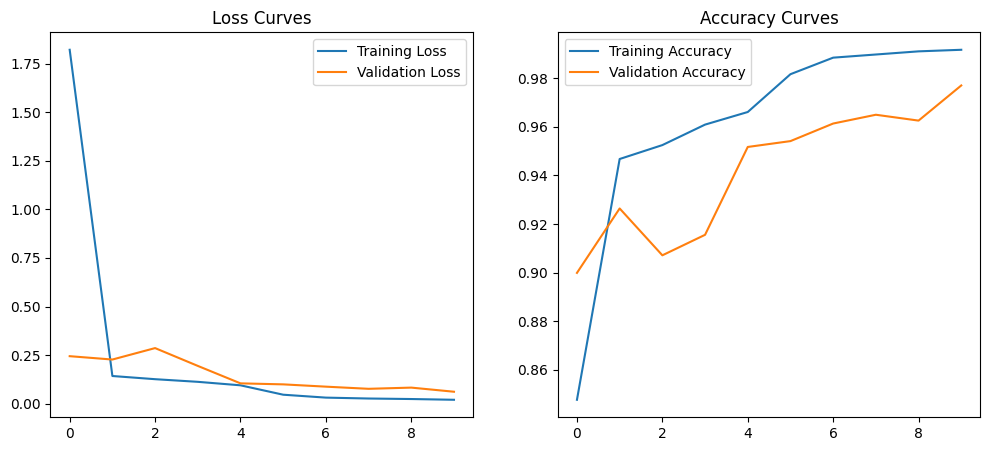

In [19]:
# Plotting Accuracy and Loss Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.show()

**Model Evaluation (Testing & Metrics)**

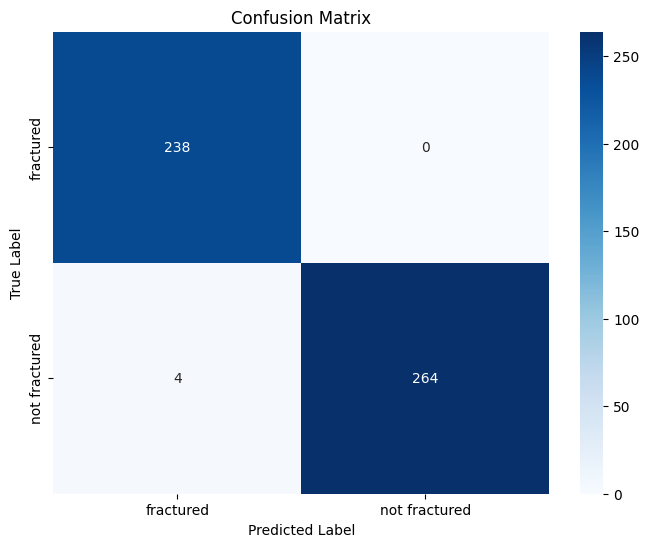

Classification Report:
               precision    recall  f1-score   support

    fractured       0.98      1.00      0.99       238
not fractured       1.00      0.99      0.99       268

     accuracy                           0.99       506
    macro avg       0.99      0.99      0.99       506
 weighted avg       0.99      0.99      0.99       506



In [20]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Comprehensive Performance Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

**Saving the Model**

In [21]:
# Save the final model weights
torch.save(model.state_dict(), 'bone_fracture_cnn_model.pth')
print("Model weights saved successfully!")

Model weights saved successfully!
